In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point,LineString,Polygon,MultiPoint

In [3]:
import os

os.listdir(r'C:\Users\SLL\Desktop\test\子流域合并')

['流域.cpg',
 '流域.dbf',
 '流域.prj',
 '流域.sbn',
 '流域.sbx',
 '流域.shp',
 '流域.shp.DESKTOP-HECM2U0.15668.7656.sr.lock',
 '流域.shp.DESKTOP-HECM2U0.17144.7656.sr.lock',
 '流域.shp.DESKTOP-HECM2U0.24376.7656.sr.lock',
 '流域.shp.DESKTOP-HECM2U0.9048.7656.sr.lock',
 '流域.shp.xml',
 '流域.shx',
 '锯齿子流域.cpg',
 '锯齿子流域.dbf',
 '锯齿子流域.prj',
 '锯齿子流域.sbn',
 '锯齿子流域.sbx',
 '锯齿子流域.shp',
 '锯齿子流域.shp.DESKTOP-HECM2U0.15668.7656.sr.lock',
 '锯齿子流域.shp.DESKTOP-HECM2U0.17144.7656.sr.lock',
 '锯齿子流域.shp.DESKTOP-HECM2U0.24376.7656.sr.lock',
 '锯齿子流域.shp.DESKTOP-HECM2U0.9048.7656.sr.lock',
 '锯齿子流域.shp.xml',
 '锯齿子流域.shx',
 '锯齿子流域1.cpg',
 '锯齿子流域1.dbf',
 '锯齿子流域1.prj',
 '锯齿子流域1.sbn',
 '锯齿子流域1.sbx',
 '锯齿子流域1.shp',
 '锯齿子流域1.shp.DESKTOP-HECM2U0.15668.7656.sr.lock',
 '锯齿子流域1.shp.DESKTOP-HECM2U0.17144.7656.sr.lock',
 '锯齿子流域1.shp.DESKTOP-HECM2U0.24376.7656.sr.lock',
 '锯齿子流域1.shp.DESKTOP-HECM2U0.9048.7656.sr.lock',
 '锯齿子流域1.shp.xml',
 '锯齿子流域1.shx']

In [4]:
#shp_a用于存储河流数据（有河流上下游拓扑结构信息）
#shp_b用于存储子流域数据（无河流上下游拓扑结构信息）

In [22]:
dt = gpd.read_file(r'C:\Users\SLL\Desktop\test\子流域合并\流域.shp')
#shp_b = gpd.GeoDataFrame(dt,columns=['LINKNO', 'DSLINKNO', 'USLINKNO1', 'USLINKNO2','strmOrder', 'geometry'])

In [24]:
dt

,OBJECTID,gridcode,COUNT,ANY_DOUTEN,ANY_DOUTMI,ANY_DOUTST,ANY_DSCont,ANY_DSLINK,ANY_DSNODE,ANY_Length,...,ANY_Straig,ANY_strmDr,ANY_strmOr,ANY_USCont,ANY_USLINK,ANY_USLI_1,ANY_WSNO,SHAPE_Leng,SHAPE_Area,geometry
0,6,526,1.0,26865.7,31799.3,36732.9,3.364122e+07,8045,-1.0,9867.1,...,8441.3,229.39,1,34.479457,-1,-1,526,45165.463783,3.447946e+07,"POLYGON ((352083.689 3936883.676, 352085.220 3..."
1,7,654,1.0,33511.9,35594.8,37677.8,1.721591e+07,6942,-1.0,4165.9,...,3693.8,119.71,1,17.653724,-1,-1,654,36600.432238,1.765372e+07,"POLYGON ((360720.936 3933322.635, 360645.338 3..."
2,5,318,1.0,81009.4,82406.3,83803.2,1.179078e+07,8574,-1.0,2793.8,...,2035.5,49.18,1,12.077855,-1,-1,318,25248.412154,1.207786e+07,"POLYGON ((406686.793 3940307.827, 406690.661 3..."
3,1,46,1.0,93757.3,96524.1,99291.0,1.941049e+07,6334,-1.0,5533.7,...,4919.7,263.10,1,19.883017,-1,-1,46,36067.723716,1.988302e+07,"POLYGON ((420978.930 3942111.677, 420827.906 3..."
4,3,174,1.0,93757.3,93942.2,94127.1,1.025048e+07,6334,-1.0,369.8,...,369.8,15.18,1,10.498263,-1,-1,174,19664.306485,1.049826e+07,"POLYGON ((415551.704 3943178.620, 415476.200 3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,153,9245,1.0,17059.6,22843.4,28627.2,2.303701e+09,9261,-1.0,11567.6,...,8783.9,87.16,4,43.932265,9229,4157,9245,43278.059063,4.393227e+07,"POLYGON ((369215.668 3945402.889, 369140.174 3..."
153,157,9309,1.0,0.0,4951.5,9903.0,2.839289e+09,-1,-1.0,9903.0,...,7979.2,160.69,4,32.187782,9293,7005,9309,34663.075410,3.218778e+07,"POLYGON ((356599.565 3959101.550, 356448.803 3..."
154,155,9277,1.0,12102.5,13251.1,14399.7,2.679738e+09,9293,-1.0,2297.1,...,1892.6,17.60,4,5.035275,9261,8397,9277,11280.097719,5.035275e+06,"POLYGON ((362121.696 3955406.682, 362123.132 3..."
155,154,9261,1.0,14399.7,15729.6,17059.6,2.561503e+09,9277,-1.0,2659.8,...,2044.2,22.95,4,8.062002,9245,8061,9261,18804.077855,8.062002e+06,"POLYGON ((363459.186 3954091.102, 363464.872 3..."


In [7]:
#shp_a = gpd.read_file(r'C:\Users\SLL\Desktop\test\子流域合并\2级水系.shp')
#shp_b = gpd.read_file(r'C:\Users\SLL\Desktop\test\子流域合并\子流域2.shp')
#out_file=r'C:\Users\SLL\Desktop\test\子流域合并'

In [8]:
shp_c = []

In [9]:
shp_c = shp_b['DSLINKNO']

In [11]:
shp_b

,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,strmOrder,geometry
0,NaN,NaN,NaN,NaN,NaN,"POLYGON ((352083.689 3936883.676, 352085.220 3..."
1,NaN,NaN,NaN,NaN,NaN,"POLYGON ((360720.936 3933322.635, 360645.338 3..."
2,NaN,NaN,NaN,NaN,NaN,"POLYGON ((406686.793 3940307.827, 406690.661 3..."
3,NaN,NaN,NaN,NaN,NaN,"POLYGON ((420978.930 3942111.677, 420827.906 3..."
4,NaN,NaN,NaN,NaN,NaN,"POLYGON ((415551.704 3943178.620, 415476.200 3..."
...,...,...,...,...,...,...
152,NaN,NaN,NaN,NaN,NaN,"POLYGON ((369215.668 3945402.889, 369140.174 3..."
153,NaN,NaN,NaN,NaN,NaN,"POLYGON ((356599.565 3959101.550, 356448.803 3..."
154,NaN,NaN,NaN,NaN,NaN,"POLYGON ((362121.696 3955406.682, 362123.132 3..."
155,NaN,NaN,NaN,NaN,NaN,"POLYGON ((363459.186 3954091.102, 363464.872 3..."


<AxesSubplot:>

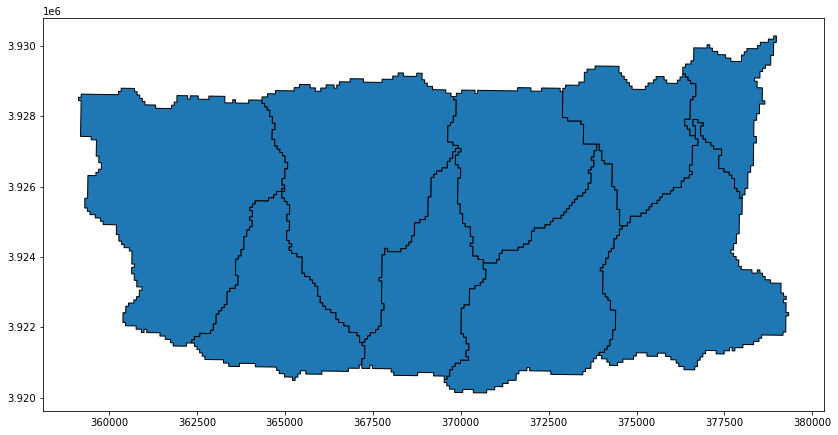

In [8]:
shp_b.plot(figsize=(14,14),edgecolor='k')

In [9]:
#datafile =gpd.sjoin(shp_b,shp_a,how="right", op='intersects') #空间连接 #使用sjoin函数进行连接 目标数据在前，连接数据在后

In [10]:
#print(datafile)

In [11]:
#datafile.plot(figsize=(14,14),edgecolor='k')

In [12]:
shp_b = shp_b[['LINKNO', 'DSLINKNO', 'USLINKNO1', 'USLINKNO2','strmOrder', 'geometry']]

In [13]:
shp_b['area'] = shp_b.area / 1000000

D:\000computersofeware\000installsoftware\002subject\Anaconda3\lib\site-packages\geopandas\geodataframe.py:1351: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [14]:
shp_b

,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,strmOrder,geometry,area
0,3022,5742,-1,-1,1,"POLYGON ((361823.726 3921466.764, 361825.149 3...",27.950228
1,3134,5742,-1,-1,1,"MULTIPOLYGON (((364918.484 3925859.114, 364915...",12.383499
2,3150,7646,-1,-1,1,"POLYGON ((376578.340 3920789.419, 376351.239 3...",20.212792
3,3390,7358,-1,-1,1,"POLYGON ((370738.746 3920131.690, 370360.209 3...",17.953987
4,5742,6814,3134,3022,2,"POLYGON ((367201.008 3921570.598, 367125.312 3...",25.505431
5,6814,7358,5742,3118,2,"POLYGON ((370640.639 3923832.524, 370641.972 3...",14.672240
6,7358,7646,6814,3390,2,"POLYGON ((374591.294 3924886.241, 374515.628 3...",10.325938
7,3118,6814,-1,-1,2,"POLYGON ((369532.801 3920519.067, 369534.145 3...",11.899375
8,7646,-1,7358,3150,2,"POLYGON ((378007.586 3925671.467, 377931.927 3...",6.155714


## 第一步：获取流域列表

In [15]:
shp_b['link'] = shp_b.apply(lambda x:{int(x[i]) for i in range(4) if x[i] != -1},axis=1)

D:\000computersofeware\000installsoftware\002subject\Anaconda3\lib\site-packages\geopandas\geodataframe.py:1351: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [16]:
shp_b

,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,strmOrder,geometry,area,link
0,3022,5742,-1,-1,1,"POLYGON ((361823.726 3921466.764, 361825.149 3...",27.950228,"{5742, 3022}"
1,3134,5742,-1,-1,1,"MULTIPOLYGON (((364918.484 3925859.114, 364915...",12.383499,"{5742, 3134}"
2,3150,7646,-1,-1,1,"POLYGON ((376578.340 3920789.419, 376351.239 3...",20.212792,"{7646, 3150}"
3,3390,7358,-1,-1,1,"POLYGON ((370738.746 3920131.690, 370360.209 3...",17.953987,"{7358, 3390}"
4,5742,6814,3134,3022,2,"POLYGON ((367201.008 3921570.598, 367125.312 3...",25.505431,"{3134, 6814, 3022, 5742}"
5,6814,7358,5742,3118,2,"POLYGON ((370640.639 3923832.524, 370641.972 3...",14.672240,"{3118, 5742, 7358, 6814}"
6,7358,7646,6814,3390,2,"POLYGON ((374591.294 3924886.241, 374515.628 3...",10.325938,"{3390, 6814, 7646, 7358}"
7,3118,6814,-1,-1,2,"POLYGON ((369532.801 3920519.067, 369534.145 3...",11.899375,"{6814, 3118}"
8,7646,-1,7358,3150,2,"POLYGON ((378007.586 3925671.467, 377931.927 3...",6.155714,"{3150, 7358, 7646}"


In [17]:
shp_b['link'][0] & shp_b['link'][1]

{5742}

In [18]:
len(shp_b['link'][0] & shp_b['link'][1]) > 0

True

## 算法 - 获取相同的流域

In [19]:
shp_b['all'] = list([shp_b['link'].values]) * 9

D:\000computersofeware\000installsoftware\002subject\Anaconda3\lib\site-packages\geopandas\geodataframe.py:1351: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [20]:
def get(x):
    base_set = x[0]
    
    for set_n in x[1]:        
        if len(x[0] & set_n) > 0:
            base_set = base_set | set_n
        else:
            pass
    
    return base_set

In [21]:
shp_b

,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,strmOrder,geometry,area,link,all
0,3022,5742,-1,-1,1,"POLYGON ((361823.726 3921466.764, 361825.149 3...",27.950228,"{5742, 3022}","[{5742, 3022}, {5742, 3134}, {7646, 3150}, {73..."
1,3134,5742,-1,-1,1,"MULTIPOLYGON (((364918.484 3925859.114, 364915...",12.383499,"{5742, 3134}","[{5742, 3022}, {5742, 3134}, {7646, 3150}, {73..."
2,3150,7646,-1,-1,1,"POLYGON ((376578.340 3920789.419, 376351.239 3...",20.212792,"{7646, 3150}","[{5742, 3022}, {5742, 3134}, {7646, 3150}, {73..."
3,3390,7358,-1,-1,1,"POLYGON ((370738.746 3920131.690, 370360.209 3...",17.953987,"{7358, 3390}","[{5742, 3022}, {5742, 3134}, {7646, 3150}, {73..."
4,5742,6814,3134,3022,2,"POLYGON ((367201.008 3921570.598, 367125.312 3...",25.505431,"{3134, 6814, 3022, 5742}","[{5742, 3022}, {5742, 3134}, {7646, 3150}, {73..."
5,6814,7358,5742,3118,2,"POLYGON ((370640.639 3923832.524, 370641.972 3...",14.672240,"{3118, 5742, 7358, 6814}","[{5742, 3022}, {5742, 3134}, {7646, 3150}, {73..."
6,7358,7646,6814,3390,2,"POLYGON ((374591.294 3924886.241, 374515.628 3...",10.325938,"{3390, 6814, 7646, 7358}","[{5742, 3022}, {5742, 3134}, {7646, 3150}, {73..."
7,3118,6814,-1,-1,2,"POLYGON ((369532.801 3920519.067, 369534.145 3...",11.899375,"{6814, 3118}","[{5742, 3022}, {5742, 3134}, {7646, 3150}, {73..."
8,7646,-1,7358,3150,2,"POLYGON ((378007.586 3925671.467, 377931.927 3...",6.155714,"{3150, 7358, 7646}","[{5742, 3022}, {5742, 3134}, {7646, 3150}, {73..."


In [22]:
shp_b[['link','all']].apply(get,axis=1)

0                 {6814, 5742, 3022, 3118, 7358, 3134}
1                 {6814, 5742, 3022, 3118, 7358, 3134}
2                       {3390, 3150, 6814, 7358, 7646}
3           {7646, 6814, 3118, 5742, 3150, 7358, 3390}
4     {3390, 7646, 6814, 3022, 3118, 5742, 3134, 7358}
5    {7646, 6814, 3022, 3118, 5742, 3150, 3134, 735...
6    {3390, 6814, 3150, 3022, 5742, 3118, 3134, 735...
7     {3390, 7646, 6814, 3022, 3118, 5742, 3134, 7358}
8           {3390, 6814, 3118, 3150, 5742, 7358, 7646}
dtype: object

In [23]:
shp_b['watershed'] = shp_b[['link','all']].apply(get,axis=1)

D:\000computersofeware\000installsoftware\002subject\Anaconda3\lib\site-packages\geopandas\geodataframe.py:1351: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [24]:
print(shp_b)

   LINKNO  DSLINKNO  USLINKNO1  USLINKNO2  strmOrder  \
0    3022      5742         -1         -1          1   
1    3134      5742         -1         -1          1   
2    3150      7646         -1         -1          1   
3    3390      7358         -1         -1          1   
4    5742      6814       3134       3022          2   
5    6814      7358       5742       3118          2   
6    7358      7646       6814       3390          2   
7    3118      6814         -1         -1          2   
8    7646        -1       7358       3150          2   

                                            geometry       area  \
0  POLYGON ((361823.726 3921466.764, 361825.149 3...  27.950228   
1  MULTIPOLYGON (((364918.484 3925859.114, 364915...  12.383499   
2  POLYGON ((376578.340 3920789.419, 376351.239 3...  20.212792   
3  POLYGON ((370738.746 3920131.690, 370360.209 3...  17.953987   
4  POLYGON ((367201.008 3921570.598, 367125.312 3...  25.505431   
5  POLYGON ((370640.639 3923832.524, 

In [25]:
{tuple(i) for i in shp_b['watershed'].values}

{(3390, 3150, 6814, 7358, 7646),
 (3390, 6814, 3118, 3150, 5742, 7358, 7646),
 (3390, 6814, 3150, 3022, 5742, 3118, 3134, 7358, 7646),
 (3390, 7646, 6814, 3022, 3118, 5742, 3134, 7358),
 (6814, 5742, 3022, 3118, 7358, 3134),
 (7646, 6814, 3022, 3118, 5742, 3150, 3134, 7358, 3390),
 (7646, 6814, 3118, 5742, 3150, 7358, 3390)}

In [26]:
{tuple(sorted(tuple(i))) for i in shp_b['watershed'].values}

{(3022, 3118, 3134, 3150, 3390, 5742, 6814, 7358, 7646),
 (3022, 3118, 3134, 3390, 5742, 6814, 7358, 7646),
 (3022, 3118, 3134, 5742, 6814, 7358),
 (3118, 3150, 3390, 5742, 6814, 7358, 7646),
 (3150, 3390, 6814, 7358, 7646)}